In [1]:
# Cell 1: Imports and configuration

import os
import random
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import rasterio


# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


# Dataset paths
BASE = Path("/Volumes/Utkash SSD/SIH26143")

OIL_DIR = BASE / "Oil"
OIL_MASK_DIR = BASE / "Mask_oil"

LOOKALIKE_DIR = BASE / "Lookalike_images" / "Lookalike"
LOOKALIKE_MASK_DIR = BASE / "Mask_lookalike"

NO_OIL_DIR = BASE / "No_Oil_images" / "No_oil"
NO_OIL_MASK_DIR = BASE / "Mask_no_oil"


# Compute device
DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)


print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
print("Dataset:", BASE)
print("Dataset exists:", BASE.exists())

PyTorch: 2.13.0
Device: mps
Dataset: /Volumes/Utkash SSD/SIH26143
Dataset exists: True


In [2]:
# Cell 2: Dataset indexing and image-mask pairing

def get_tif_files(folder):
    return sorted(folder.glob("*.tif"))


def build_pairs(image_dir, mask_dir, label):
    images = get_tif_files(image_dir)
    masks = get_tif_files(mask_dir)

    image_ids = {path.stem for path in images}
    mask_ids = {path.stem for path in masks}

    missing_masks = sorted(image_ids - mask_ids)
    missing_images = sorted(mask_ids - image_ids)

    pairs = [
        (
            image_path,
            mask_dir / f"{image_path.stem}.tif",
            label
        )
        for image_path in images
        if image_path.stem in mask_ids
    ]

    print(
        f"{label:12s} | "
        f"images: {len(images):4d} | "
        f"masks: {len(masks):4d} | "
        f"pairs: {len(pairs):4d}"
    )

    if missing_masks:
        print("  Missing masks :", len(missing_masks))

    if missing_images:
        print("  Missing images:", len(missing_images))

    return pairs


oil_pairs = build_pairs(
    OIL_DIR,
    OIL_MASK_DIR,
    "Oil"
)

lookalike_pairs = build_pairs(
    LOOKALIKE_DIR,
    LOOKALIKE_MASK_DIR,
    "Lookalike"
)

no_oil_pairs = build_pairs(
    NO_OIL_DIR,
    NO_OIL_MASK_DIR,
    "No-Oil"
)


all_pairs = (
    oil_pairs
    + lookalike_pairs
    + no_oil_pairs
)


print()
print("TOTAL VALID PAIRS:", len(all_pairs))

Oil          | images: 1200 | masks: 1200 | pairs: 1200
Lookalike    | images:  685 | masks:  685 | pairs:  685
No-Oil       | images:  685 | masks:  685 | pairs:  685

TOTAL VALID PAIRS: 2570


In [3]:
# Cell 3: Train-validation split

VAL_RATIO = 0.15


def split_pairs(pairs, val_ratio=VAL_RATIO):
    pairs = pairs.copy()
    random.shuffle(pairs)

    val_size = int(len(pairs) * val_ratio)

    val_pairs = pairs[:val_size]
    train_pairs = pairs[val_size:]

    return train_pairs, val_pairs


# Split each class separately to preserve class balance
oil_train, oil_val = split_pairs(oil_pairs)
lookalike_train, lookalike_val = split_pairs(lookalike_pairs)
no_oil_train, no_oil_val = split_pairs(no_oil_pairs)


# Combine the splits
train_pairs = oil_train + lookalike_train + no_oil_train
val_pairs = oil_val + lookalike_val + no_oil_val


# Shuffle combined datasets
random.shuffle(train_pairs)
random.shuffle(val_pairs)


print("Training samples:", len(train_pairs))
print("Validation samples:", len(val_pairs))

print()
print("Training:")
print("  Oil       :", len(oil_train))
print("  Lookalike :", len(lookalike_train))
print("  No-Oil    :", len(no_oil_train))

print()
print("Validation:")
print("  Oil       :", len(oil_val))
print("  Lookalike :", len(lookalike_val))
print("  No-Oil    :", len(no_oil_val))

Training samples: 2186
Validation samples: 384

Training:
  Oil       : 1020
  Lookalike : 583
  No-Oil    : 583

Validation:
  Oil       : 180
  Lookalike : 102
  No-Oil    : 102


In [4]:
# Cell 4: Training configuration

IMAGE_SIZE = 256
PATCH_STRIDE = 256

BATCH_SIZE = 4
NUM_WORKERS = 0

LEARNING_RATE = 1e-4
NUM_EPOCHS = 10

print("Patch size:", f"{IMAGE_SIZE}x{IMAGE_SIZE}")
print("Patch stride:", PATCH_STRIDE)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Epochs:", NUM_EPOCHS)
print("Device:", DEVICE)

Patch size: 256x256
Patch stride: 256
Batch size: 4
Learning rate: 0.0001
Epochs: 10
Device: mps


In [5]:
# Cell 5: Dataset and DataLoaders

class OilSpillDataset(Dataset):
    def __init__(self, pairs, patch_size=256, positive_crop_prob=0.7):
        self.pairs = pairs
        self.patch_size = patch_size
        self.positive_crop_prob = positive_crop_prob

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        image_path, mask_path, label = self.pairs[index]

        with rasterio.open(image_path) as src:
            image = src.read().astype(np.float32)

        with rasterio.open(mask_path) as src:
            mask = src.read(1).astype(np.float32)

        # Normalize each SAR band independently
        for band in range(image.shape[0]):
            low = np.percentile(image[band], 1)
            high = np.percentile(image[band], 99)

            image[band] = np.clip(
                (image[band] - low) / (high - low + 1e-6),
                0,
                1
            )

        height, width = mask.shape

        max_y = height - self.patch_size
        max_x = width - self.patch_size

        has_spill = mask.max() > 0

        # Sample around a positive pixel for oil images
        if (
            label == "Oil"
            and has_spill
            and random.random() < self.positive_crop_prob
        ):
            ys, xs = np.where(mask > 0)

            center_y = random.choice(ys)
            center_x = random.choice(xs)

            y = np.clip(
                center_y - self.patch_size // 2,
                0,
                max_y
            )

            x = np.clip(
                center_x - self.patch_size // 2,
                0,
                max_x
            )

        else:
            y = random.randint(0, max_y)
            x = random.randint(0, max_x)

        image = image[
            :,
            y:y + self.patch_size,
            x:x + self.patch_size
        ]

        mask = mask[
            y:y + self.patch_size,
            x:x + self.patch_size
        ]

        image = torch.from_numpy(image).float()
        mask = torch.from_numpy(mask).float().unsqueeze(0)

        return image, mask


train_dataset = OilSpillDataset(
    train_pairs,
    patch_size=IMAGE_SIZE,
    positive_crop_prob=0.7
)

val_dataset = OilSpillDataset(
    val_pairs,
    patch_size=IMAGE_SIZE,
    positive_crop_prob=0.7
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)


print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train samples: 2186
Validation samples: 384
Train batches: 547
Validation batches: 96


/opt/anaconda3/lib/python3.13/site-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Image batch shape: (4, 2, 256, 256)
Mask batch shape : (4, 1, 256, 256)
Image dtype: torch.float32
Mask dtype : torch.float32
Image range: 0.0000 to 1.0000
Mask unique values: [0.0]

Mask coverage per sample:
Sample 1: 0.00%
Sample 2: 0.00%
Sample 3: 0.00%
Sample 4: 0.00%


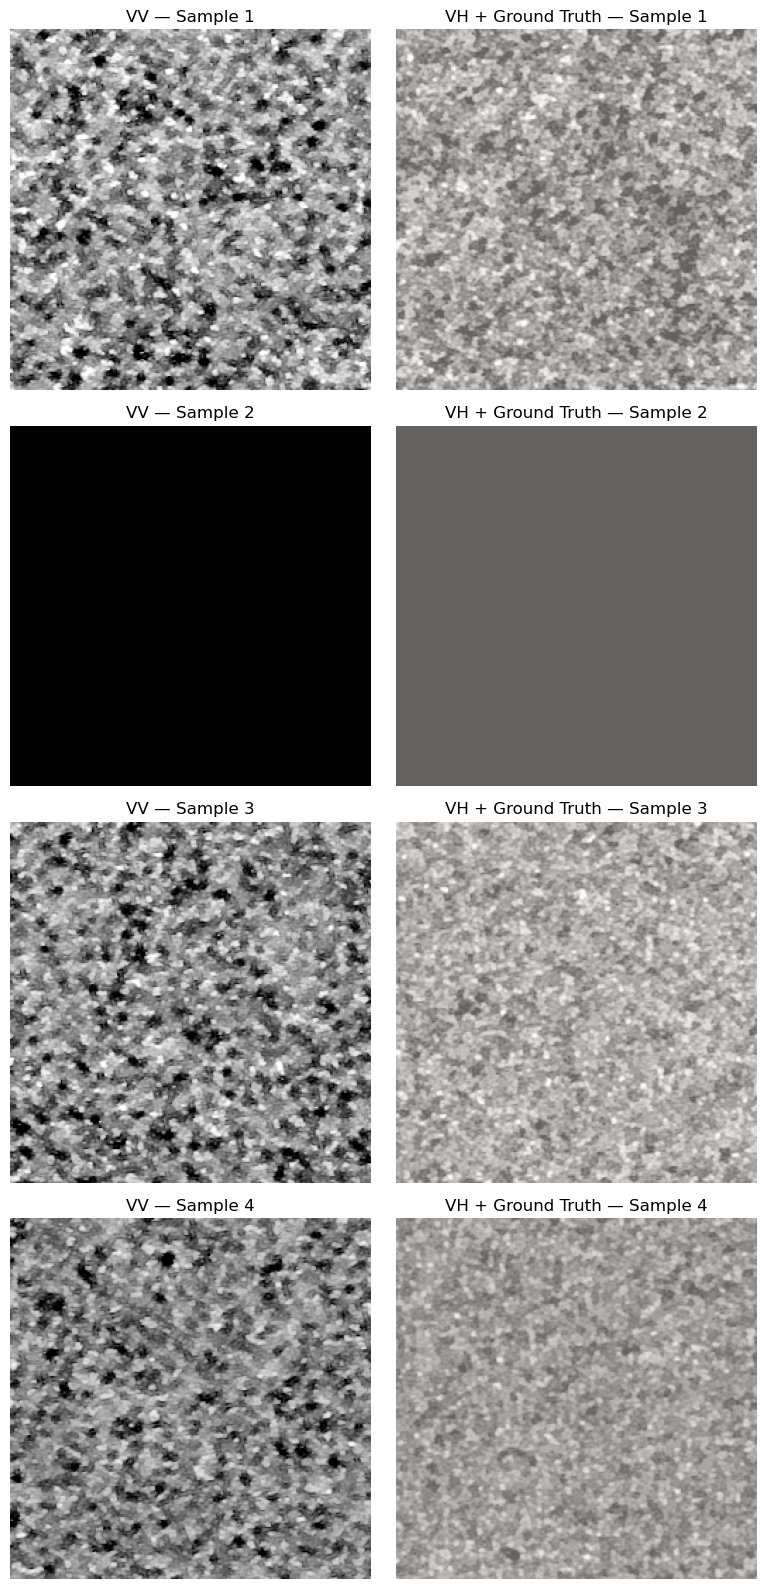

In [6]:
# Cell 6: Dataset sanity check

images, masks = next(iter(train_loader))

print("Image batch shape:", tuple(images.shape))
print("Mask batch shape :", tuple(masks.shape))

print("Image dtype:", images.dtype)
print("Mask dtype :", masks.dtype)

print(
    "Image range:",
    f"{images.min().item():.4f}",
    "to",
    f"{images.max().item():.4f}"
)

print("Mask unique values:", torch.unique(masks).tolist())

print()
print("Mask coverage per sample:")

for i in range(len(masks)):
    coverage = (masks[i, 0] > 0).float().mean().item() * 100
    print(f"Sample {i + 1}: {coverage:.2f}%")


# Visualize the batch
num_samples = min(4, len(images))

fig, axes = plt.subplots(
    num_samples,
    2,
    figsize=(8, 4 * num_samples)
)

if num_samples == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(num_samples):
    axes[i, 0].imshow(images[i, 0], cmap="gray")
    axes[i, 0].set_title(f"VV — Sample {i + 1}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(images[i, 1], cmap="gray")
    axes[i, 1].imshow(
        masks[i, 0],
        cmap="Reds",
        alpha=0.4
    )
    axes[i, 1].set_title(
        f"VH + Ground Truth — Sample {i + 1}"
    )
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [7]:
# Cell 7: Lightweight U-Net

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=2, out_channels=1):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)

        self.pool = nn.MaxPool2d(kernel_size=2)

        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(
            256, 128, kernel_size=2, stride=2
        )
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(
            128, 64, kernel_size=2, stride=2
        )
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(
            64, 32, kernel_size=2, stride=2
        )
        self.dec1 = DoubleConv(64, 32)

        self.output = nn.Conv2d(
            32,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):
        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        b = self.bottleneck(
            self.pool(e3)
        )

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.output(d1)


model = UNet(
    in_channels=2,
    out_channels=1
).to(DEVICE)


num_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print("Model:", model.__class__.__name__)
print("Parameters:", f"{num_parameters:,}")
print("Device:", DEVICE)

Model: UNet
Parameters: 1,926,721
Device: mps


In [8]:
# Cell 8: Model forward-pass test

model.eval()

test_images, test_masks = next(iter(train_loader))

test_images = test_images.to(DEVICE)
test_masks = test_masks.to(DEVICE)

with torch.no_grad():
    start_time = time.time()

    test_outputs = model(test_images)

    elapsed = time.time() - start_time


print("Input shape :", tuple(test_images.shape))
print("Output shape:", tuple(test_outputs.shape))
print("Target shape:", tuple(test_masks.shape))

print("Forward pass:", f"{elapsed:.2f} seconds")
print("Output dtype :", test_outputs.dtype)
print(
    "Output range :",
    f"{test_outputs.min().item():.4f}",
    "to",
    f"{test_outputs.max().item():.4f}"
)

if DEVICE.type == "mps":
    print(
        "MPS memory allocated:",
        f"{torch.mps.current_allocated_memory() / 1024**3:.2f} GB"
    )

Input shape : (4, 2, 256, 256)
Output shape: (4, 1, 256, 256)
Target shape: (4, 1, 256, 256)
Forward pass: 0.90 seconds
Output dtype : torch.float32
Output range : -0.1582 to -0.1450
MPS memory allocated: 0.01 GB


In [9]:
# Cell 9: Loss function and segmentation metrics

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probabilities = torch.sigmoid(logits)

        probabilities = probabilities.flatten(1)
        targets = targets.flatten(1)

        intersection = (probabilities * targets).sum(dim=1)

        dice = (
            (2 * intersection + self.smooth)
            / (
                probabilities.sum(dim=1)
                + targets.sum(dim=1)
                + self.smooth
            )
        )

        return 1 - dice.mean()


class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()

        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits, targets):
        return self.bce(logits, targets) + self.dice(logits, targets)


criterion = BCEDiceLoss()


def segmentation_metrics(
    logits,
    targets,
    threshold=0.5,
    smooth=1e-6
):
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities >= threshold).float()

    predictions = predictions.flatten()
    targets = targets.flatten()

    true_positive = (predictions * targets).sum()
    false_positive = (predictions * (1 - targets)).sum()
    false_negative = ((1 - predictions) * targets).sum()

    dice = (
        (2 * true_positive + smooth)
        / (
            2 * true_positive
            + false_positive
            + false_negative
            + smooth
        )
    )

    iou = (
        (true_positive + smooth)
        / (
            true_positive
            + false_positive
            + false_negative
            + smooth
        )
    )

    precision = (
        (true_positive + smooth)
        / (
            true_positive
            + false_positive
            + smooth
        )
    )

    recall = (
        (true_positive + smooth)
        / (
            true_positive
            + false_negative
            + smooth
        )
    )

    return {
        "dice": dice.item(),
        "iou": iou.item(),
        "precision": precision.item(),
        "recall": recall.item()
    }


print("Loss:", criterion.__class__.__name__)
print("Metrics: Dice, IoU, Precision, Recall")

Loss: BCEDiceLoss
Metrics: Dice, IoU, Precision, Recall


In [10]:
# Cell 10: Optimizer and learning rate scheduler

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)


best_val_dice = 0.0

history = {
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": [],
    "val_precision": [],
    "val_recall": []
}


print("Optimizer:", optimizer.__class__.__name__)
print("Initial learning rate:", LEARNING_RATE)
print("Weight decay:", 1e-4)
print("Scheduler:", scheduler.__class__.__name__)

Optimizer: AdamW
Initial learning rate: 0.0001
Weight decay: 0.0001
Scheduler: ReduceLROnPlateau


In [11]:
# Cell 11: Training and validation functions

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def validate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0

    metric_totals = {
        "dice": 0.0,
        "iou": 0.0,
        "precision": 0.0,
        "recall": 0.0
    }

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)
            total_loss += loss.item()

            metrics = segmentation_metrics(
                outputs,
                masks
            )

            for name in metric_totals:
                metric_totals[name] += metrics[name]

    num_batches = len(loader)

    return (
        total_loss / num_batches,
        {
            name: value / num_batches
            for name, value in metric_totals.items()
        }
    )


print("Training function ready.")
print("Validation function ready.")

Training function ready.
Validation function ready.


In [ ]:
# Cell 12: Single-batch training speed test

model.train()

test_images, test_masks = next(iter(train_loader))

test_images = test_images.to(DEVICE)
test_masks = test_masks.to(DEVICE)

optimizer.zero_grad()

start_time = time.time()

test_outputs = model(test_images)
test_loss = criterion(test_outputs, test_masks)

test_loss.backward()
optimizer.step()

elapsed = time.time() - start_time


print("Batch image shape :", tuple(test_images.shape))
print("Model output shape:", tuple(test_outputs.shape))
print("Test loss         :", f"{test_loss.item():.4f}")
print("Training step     :", f"{elapsed:.2f} seconds")

if DEVICE.type == "mps":
    print(
        "MPS memory allocated:",
        f"{torch.mps.current_allocated_memory() / 1024**3:.2f} GB"
    )

/opt/anaconda3/lib/python3.13/site-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Batch image shape : (4, 2, 256, 256)
Model output shape: (4, 1, 256, 256)
Test loss         : 1.6061
Training step     : 1.76 seconds
MPS memory allocated: 0.07 GB


In [ ]:
# Cell 13: Full training loop

MODEL_PATH = BASE / "best_oil_spill_unet.pth"

best_val_dice = 0.0

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        DEVICE
    )

    val_loss, metrics = validate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    scheduler.step(metrics["dice"])

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(metrics["dice"])
    history["val_iou"].append(metrics["iou"])
    history["val_precision"].append(metrics["precision"])
    history["val_recall"].append(metrics["recall"])

    # Save the best model
    if metrics["dice"] > best_val_dice:
        best_val_dice = metrics["dice"]

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "val_dice": best_val_dice,
                "epoch": epoch + 1,
            },
            MODEL_PATH
        )

        saved = " [BEST MODEL SAVED]"
    else:
        saved = ""

    epoch_time = time.time() - epoch_start
    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Dice: {metrics['dice']:.4f} | "
        f"IoU: {metrics['iou']:.4f} | "
        f"Precision: {metrics['precision']:.4f} | "
        f"Recall: {metrics['recall']:.4f} | "
        f"LR: {current_lr:.2e} | "
        f"Time: {epoch_time / 60:.1f} min"
        f"{saved}"
    )

print()
print("Training complete.")
print("Best validation Dice:", f"{best_val_dice:.4f}")
print("Best model:", MODEL_PATH)

Epoch 01/10 | Train Loss: 1.2418 | Val Loss: 1.0982 | Dice: 0.5494 | IoU: 0.4651 | Precision: 0.5631 | Recall: 0.8483 | LR: 1.00e-04 | Time: 15.6 min [BEST MODEL SAVED]
Epoch 02/10 | Train Loss: 1.1009 | Val Loss: 1.0480 | Dice: 0.5843 | IoU: 0.4994 | Precision: 0.6945 | Recall: 0.7471 | LR: 1.00e-04 | Time: 15.0 min [BEST MODEL SAVED]


In [13]:
# Cell 14: Recover saved checkpoint

from pathlib import Path
import torch

BASE = Path("/Volumes/Utkash SSD/SIH26143")
MODEL_PATH = BASE / "best_oil_spill_unet.pth"

print("Checkpoint exists:", MODEL_PATH.exists())
print("Checkpoint path:", MODEL_PATH)

if MODEL_PATH.exists():
    print("Checkpoint size:", f"{MODEL_PATH.stat().st_size / 1024**2:.2f} MB")

Checkpoint exists: True
Checkpoint path: /Volumes/Utkash SSD/SIH26143/best_oil_spill_unet.pth
Checkpoint size: 7.39 MB


In [14]:
# Cell 15: Load the saved model checkpoint

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

best_val_dice = checkpoint["val_dice"]

start_epoch = checkpoint["epoch"]

print("Checkpoint loaded successfully.")
print("Resuming from epoch:", start_epoch)
print("Saved validation Dice:", f"{best_val_dice:.4f}")

Checkpoint loaded successfully.
Resuming from epoch: 2
Saved validation Dice: 0.5843


In [15]:
# Cell 16: Resume training from the saved checkpoint

for epoch in range(start_epoch, NUM_EPOCHS):
    epoch_start = time.time()

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        DEVICE
    )

    val_loss, metrics = validate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    scheduler.step(metrics["dice"])

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(metrics["dice"])
    history["val_iou"].append(metrics["iou"])
    history["val_precision"].append(metrics["precision"])
    history["val_recall"].append(metrics["recall"])

    if metrics["dice"] > best_val_dice:
        best_val_dice = metrics["dice"]

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "val_dice": best_val_dice,
                "epoch": epoch + 1,
            },
            MODEL_PATH
        )

        saved = " [BEST MODEL SAVED]"
    else:
        saved = ""

    epoch_time = time.time() - epoch_start
    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Dice: {metrics['dice']:.4f} | "
        f"IoU: {metrics['iou']:.4f} | "
        f"Precision: {metrics['precision']:.4f} | "
        f"Recall: {metrics['recall']:.4f} | "
        f"LR: {current_lr:.2e} | "
        f"Time: {epoch_time / 60:.1f} min"
        f"{saved}"
    )

print()
print("Training complete.")
print("Best validation Dice:", f"{best_val_dice:.4f}")
print("Best model:", MODEL_PATH)

/opt/anaconda3/lib/python3.13/site-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Epoch 03/10 | Train Loss: 1.0115 | Val Loss: 0.9652 | Dice: 0.5533 | IoU: 0.4744 | Precision: 0.5952 | Recall: 0.8085 | LR: 1.00e-04 | Time: 15.4 min
Epoch 04/10 | Train Loss: 0.9591 | Val Loss: 1.0028 | Dice: 0.4439 | IoU: 0.3687 | Precision: 0.4456 | Recall: 0.8239 | LR: 1.00e-04 | Time: 15.5 min
Epoch 05/10 | Train Loss: 0.9397 | Val Loss: 0.8795 | Dice: 0.5848 | IoU: 0.5014 | Precision: 0.6190 | Recall: 0.8400 | LR: 1.00e-04 | Time: 14.9 min [BEST MODEL SAVED]
Epoch 06/10 | Train Loss: 0.9145 | Val Loss: 0.9340 | Dice: 0.5683 | IoU: 0.4890 | Precision: 0.5784 | Recall: 0.8710 | LR: 1.00e-04 | Time: 15.4 min
Epoch 07/10 | Train Loss: 0.9015 | Val Loss: 0.8842 | Dice: 0.6531 | IoU: 0.5615 | Precision: 0.7093 | Recall: 0.7957 | LR: 1.00e-04 | Time: 14.9 min [BEST MODEL SAVED]
Epoch 08/10 | Train Loss: 0.8942 | Val Loss: 0.8921 | Dice: 0.6641 | IoU: 0.5868 | Precision: 0.7132 | Recall: 0.8180 | LR: 1.00e-04 | Time: 15.0 min [BEST MODEL SAVED]
Epoch 09/10 | Train Loss: 0.8979 | Val Loss

In [16]:
# Cell 17: Load best model and create deterministic validation dataset

# Load the best checkpoint
checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Best model loaded.")
print("Saved epoch:", checkpoint["epoch"])
print("Saved validation Dice:", f"{checkpoint['val_dice']:.4f}")


class FixedValidationDataset(Dataset):
    def __init__(self, pairs, patch_size=256):
        self.pairs = pairs
        self.patch_size = patch_size

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        image_path, mask_path, label = self.pairs[index]

        with rasterio.open(image_path) as src:
            image = src.read().astype(np.float32)

        with rasterio.open(mask_path) as src:
            mask = src.read(1).astype(np.float32)

        # Same normalization used during training
        for band in range(image.shape[0]):
            low = np.percentile(image[band], 1)
            high = np.percentile(image[band], 99)

            image[band] = np.clip(
                (image[band] - low) / (high - low + 1e-6),
                0,
                1
            )

        height, width = mask.shape

        # Fixed top-left crop
        image = image[
            :,
            0:self.patch_size,
            0:self.patch_size
        ]

        mask = mask[
            0:self.patch_size,
            0:self.patch_size
        ]

        image = torch.from_numpy(image).float()
        mask = torch.from_numpy(mask).float().unsqueeze(0)

        return image, mask, label


fixed_val_dataset = FixedValidationDataset(
    val_pairs,
    patch_size=IMAGE_SIZE
)

fixed_val_loader = DataLoader(
    fixed_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)


print("Fixed validation samples:", len(fixed_val_dataset))
print("Fixed validation batches:", len(fixed_val_loader))

Best model loaded.
Saved epoch: 10
Saved validation Dice: 0.6650
Fixed validation samples: 384
Fixed validation batches: 96


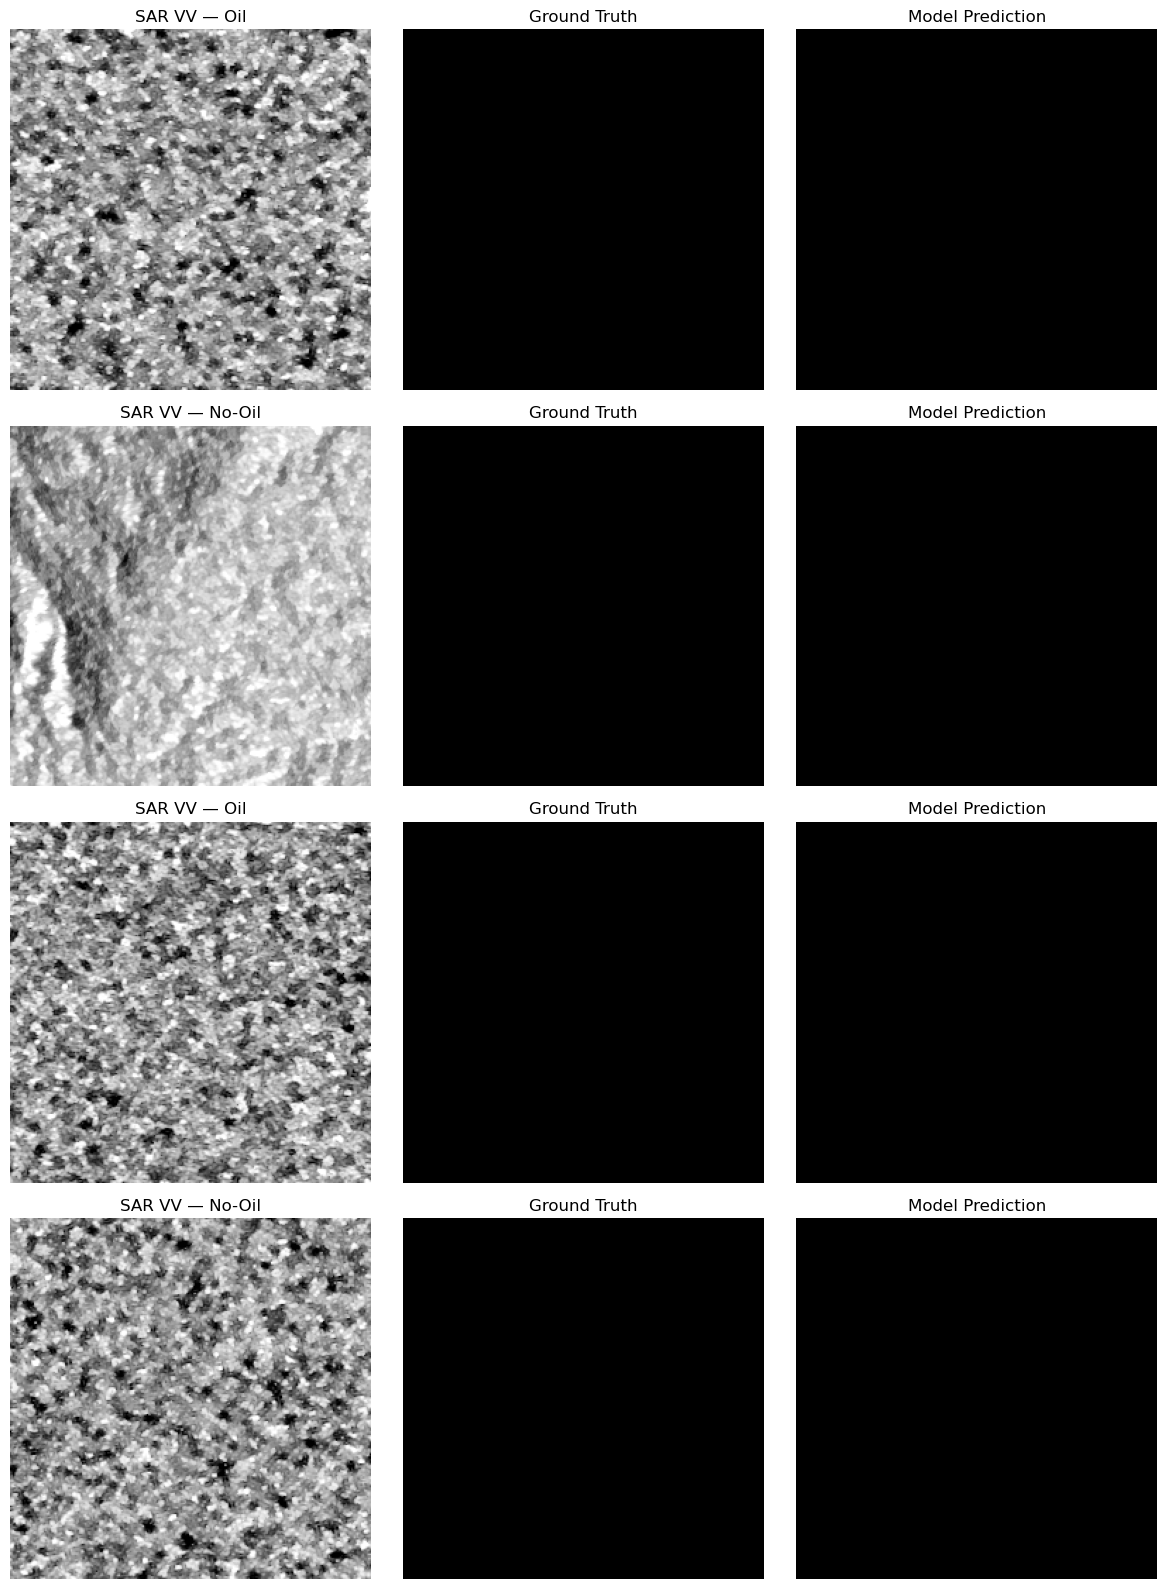

In [17]:
# Cell 18: Visualize model predictions

model.eval()

num_samples = 4

fig, axes = plt.subplots(
    num_samples,
    3,
    figsize=(12, 4 * num_samples)
)

shown = 0

with torch.no_grad():
    for images, masks, labels in fixed_val_loader:

        images = images.to(DEVICE)

        outputs = model(images)
        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities >= 0.5).float()

        for i in range(images.shape[0]):
            if shown >= num_samples:
                break

            image = images[i].cpu()
            mask = masks[i, 0]
            prediction = predictions[i, 0].cpu()

            axes[shown, 0].imshow(
                image[0],
                cmap="gray"
            )
            axes[shown, 0].set_title(
                f"SAR VV — {labels[i]}"
            )
            axes[shown, 0].axis("off")

            axes[shown, 1].imshow(
                mask,
                cmap="gray"
            )
            axes[shown, 1].set_title(
                "Ground Truth"
            )
            axes[shown, 1].axis("off")

            axes[shown, 2].imshow(
                prediction,
                cmap="gray"
            )
            axes[shown, 2].set_title(
                "Model Prediction"
            )
            axes[shown, 2].axis("off")

            shown += 1

        if shown >= num_samples:
            break

plt.tight_layout()
plt.show()

In [18]:
# Cell 19: Select deterministic positive validation samples

positive_val_pairs = [
    pair
    for pair in val_pairs
    if pair[2] == "Oil"
]

print("Oil validation images:", len(positive_val_pairs))

for i, (image_path, mask_path, label) in enumerate(
    positive_val_pairs[:5]
):
    with rasterio.open(mask_path) as src:
        mask = src.read(1)

    ys, xs = np.where(mask > 0)

    print(
        f"Sample {i + 1}:",
        image_path.name,
        "| positive pixels:",
        len(xs)
    )

Oil validation images: 180
Sample 1: 00899.tif | positive pixels: 235983
Sample 2: 01170.tif | positive pixels: 112574
Sample 3: 00961.tif | positive pixels: 12585
Sample 4: 00464.tif | positive pixels: 480067
Sample 5: 00175.tif | positive pixels: 318892


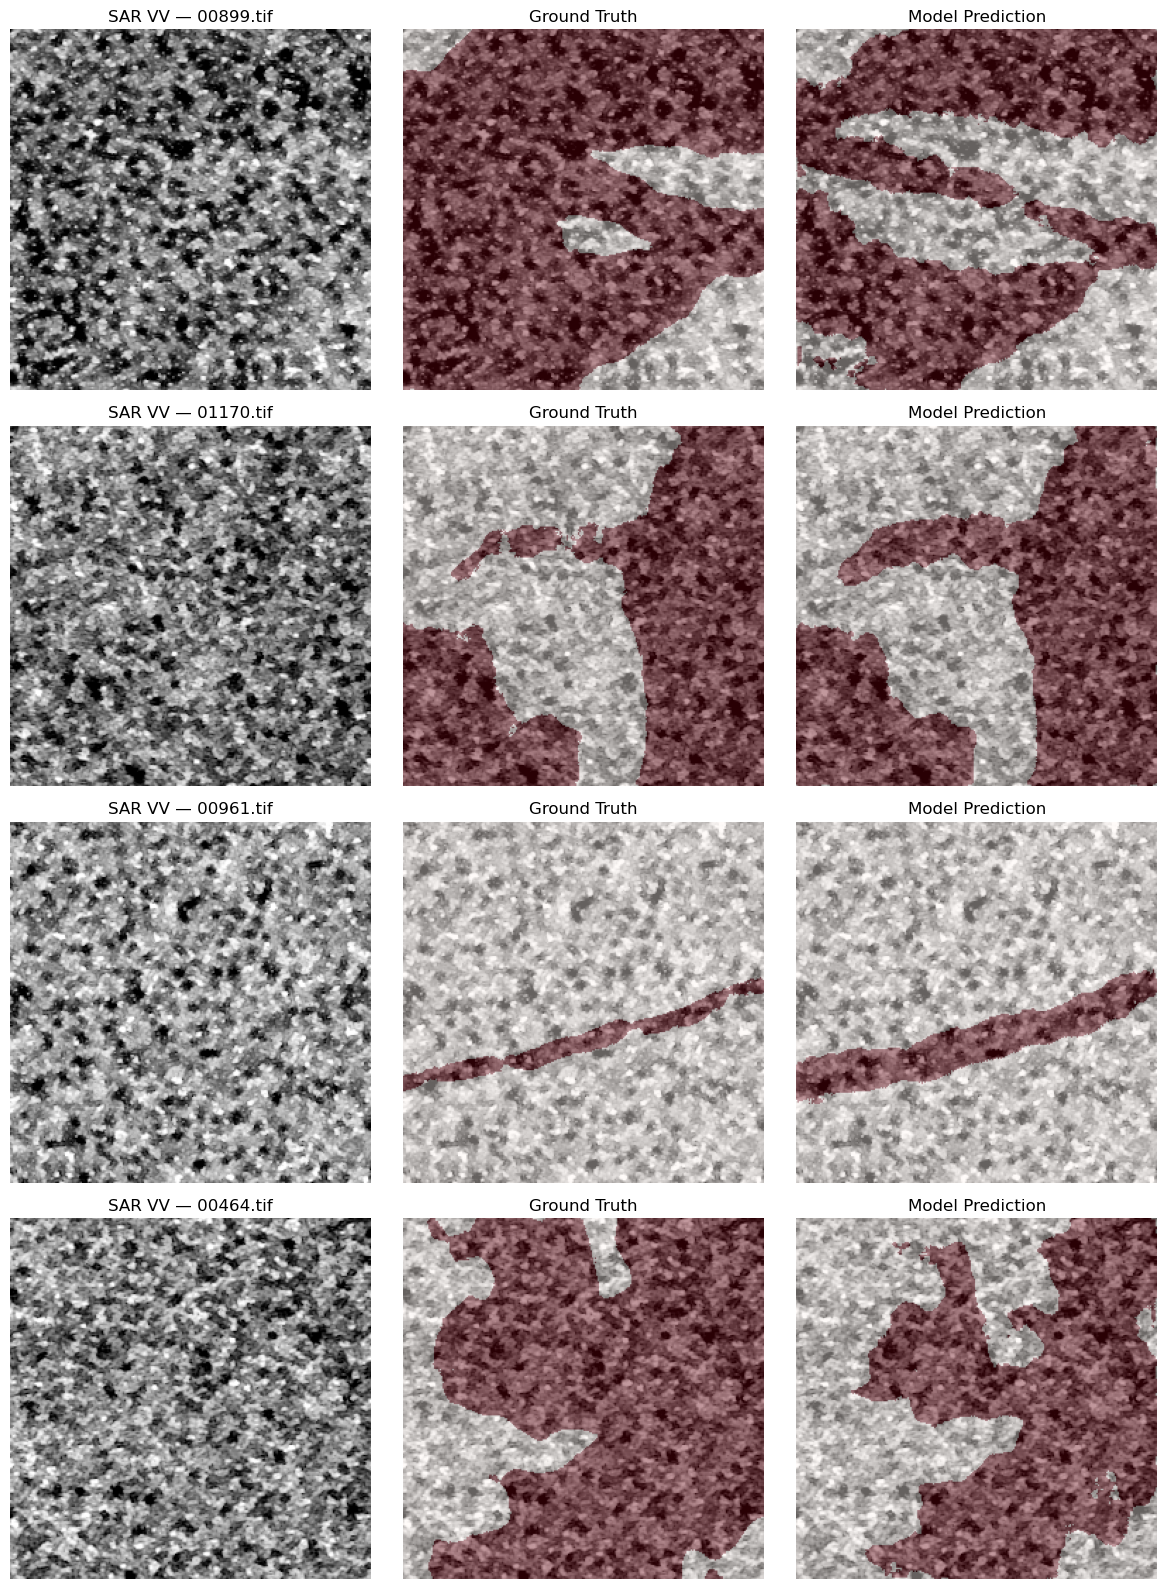

In [19]:
# Cell 20: Visualize predictions on actual spill regions

model.eval()

num_samples = 4

fig, axes = plt.subplots(
    num_samples,
    3,
    figsize=(12, 4 * num_samples)
)

for row, pair in enumerate(positive_val_pairs[:num_samples]):
    image_path, mask_path, label = pair

    with rasterio.open(image_path) as src:
        image = src.read().astype(np.float32)

    with rasterio.open(mask_path) as src:
        mask = src.read(1).astype(np.float32)

    # Normalize SAR bands
    for band in range(image.shape[0]):
        low = np.percentile(image[band], 1)
        high = np.percentile(image[band], 99)

        image[band] = np.clip(
            (image[band] - low) / (high - low + 1e-6),
            0,
            1
        )

    # Find spill center
    ys, xs = np.where(mask > 0)

    center_y = int(np.mean(ys))
    center_x = int(np.mean(xs))

    # Create a fixed crop around the spill center
    half = IMAGE_SIZE // 2

    height, width = mask.shape

    y = np.clip(
        center_y - half,
        0,
        height - IMAGE_SIZE
    )

    x = np.clip(
        center_x - half,
        0,
        width - IMAGE_SIZE
    )

    image_crop = image[
        :,
        y:y + IMAGE_SIZE,
        x:x + IMAGE_SIZE
    ]

    mask_crop = mask[
        y:y + IMAGE_SIZE,
        x:x + IMAGE_SIZE
    ]

    # Convert image to tensor
    image_tensor = torch.from_numpy(
        image_crop
    ).float().unsqueeze(0).to(DEVICE)

    # Model prediction
    with torch.no_grad():
        output = model(image_tensor)
        probability = torch.sigmoid(output)[0, 0].cpu()

    prediction = (probability >= 0.5).float()

    # Plot SAR image
    axes[row, 0].imshow(
        image_crop[0],
        cmap="gray"
    )
    axes[row, 0].set_title(
        f"SAR VV — {image_path.name}"
    )
    axes[row, 0].axis("off")

    # Ground truth
    axes[row, 1].imshow(
        image_crop[0],
        cmap="gray"
    )
    axes[row, 1].imshow(
        mask_crop,
        cmap="Reds",
        alpha=0.4
    )
    axes[row, 1].set_title(
        "Ground Truth"
    )
    axes[row, 1].axis("off")

    # Prediction
    axes[row, 2].imshow(
        image_crop[0],
        cmap="gray"
    )
    axes[row, 2].imshow(
        prediction,
        cmap="Reds",
        alpha=0.4
    )
    axes[row, 2].set_title(
        "Model Prediction"
    )
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

In [21]:
# Cell 21: Full-image deterministic validation

model.eval()

PATCH_SIZE = IMAGE_SIZE
STRIDE = IMAGE_SIZE


def normalize_sar(image):
    image = image.astype(np.float32)

    for band in range(image.shape[0]):
        low = np.percentile(image[band], 1)
        high = np.percentile(image[band], 99)

        image[band] = np.clip(
            (image[band] - low) / (high - low + 1e-6),
            0,
            1
        )

    return image


def predict_full_image(image, model, device):
    height, width = image.shape[1], image.shape[2]

    probability_map = np.zeros(
        (height, width),
        dtype=np.float32
    )

    with torch.no_grad():
        for y in range(0, height, STRIDE):
            for x in range(0, width, STRIDE):

                y_end = min(y + PATCH_SIZE, height)
                x_end = min(x + PATCH_SIZE, width)

                patch = image[
                    :,
                    y:y_end,
                    x:x_end
                ]

                patch_height = patch.shape[1]
                patch_width = patch.shape[2]

                # Pad edge patches if necessary
                if (
                    patch_height != PATCH_SIZE
                    or patch_width != PATCH_SIZE
                ):
                    padded = np.zeros(
                        (image.shape[0], PATCH_SIZE, PATCH_SIZE),
                        dtype=np.float32
                    )

                    padded[
                        :,
                        :patch_height,
                        :patch_width
                    ] = patch

                    patch = padded

                patch_tensor = torch.from_numpy(
                    patch
                ).float().unsqueeze(0).to(device)

                output = model(patch_tensor)

                probability = torch.sigmoid(
                    output
                )[0, 0].cpu().numpy()

                probability_map[
                    y:y_end,
                    x:x_end
                ] = probability[
                    :patch_height,
                    :patch_width
                ]

    return probability_map


total_tp = 0
total_fp = 0
total_fn = 0

num_images = len(val_pairs)

start_time = time.time()

for index, (image_path, mask_path, label) in enumerate(val_pairs):

    with rasterio.open(image_path) as src:
        image = src.read()

    with rasterio.open(mask_path) as src:
        mask = src.read(1)

    image = normalize_sar(image)

    probability_map = predict_full_image(
        image,
        model,
        DEVICE
    )

    prediction = probability_map >= 0.5
    target = mask > 0

    total_tp += np.logical_and(
        prediction,
        target
    ).sum()

    total_fp += np.logical_and(
        prediction,
        ~target
    ).sum()

    total_fn += np.logical_and(
        ~prediction,
        target
    ).sum()

    if (index + 1) % 25 == 0:
        elapsed = time.time() - start_time

        print(
            f"Processed {index + 1}/{num_images} "
            f"validation images | "
            f"Time: {elapsed / 60:.1f} min"
        )


smooth = 1e-6

dice = (
    (2 * total_tp + smooth)
    / (
        2 * total_tp
        + total_fp
        + total_fn
        + smooth
    )
)

iou = (
    (total_tp + smooth)
    / (
        total_tp
        + total_fp
        + total_fn
        + smooth
    )
)

precision = (
    (total_tp + smooth)
    / (
        total_tp
        + total_fp
        + smooth
    )
)

recall = (
    (total_tp + smooth)
    / (
        total_tp
        + total_fn
        + smooth
    )
)


elapsed = time.time() - start_time

print()
print("Full-image validation complete.")
print("Images evaluated:", num_images)
print("Dice      :", f"{dice:.4f}")
print("IoU       :", f"{iou:.4f}")
print("Precision :", f"{precision:.4f}")
print("Recall    :", f"{recall:.4f}")
print("Total time:", f"{elapsed / 60:.1f} min")

Processed 25/384 validation images | Time: 0.6 min
Processed 50/384 validation images | Time: 1.2 min
Processed 75/384 validation images | Time: 1.8 min
Processed 100/384 validation images | Time: 2.4 min
Processed 125/384 validation images | Time: 3.0 min
Processed 150/384 validation images | Time: 3.6 min
Processed 175/384 validation images | Time: 4.1 min
Processed 200/384 validation images | Time: 4.8 min
Processed 225/384 validation images | Time: 5.4 min
Processed 250/384 validation images | Time: 6.0 min
Processed 275/384 validation images | Time: 6.9 min
Processed 300/384 validation images | Time: 7.6 min
Processed 325/384 validation images | Time: 8.3 min
Processed 350/384 validation images | Time: 8.9 min
Processed 375/384 validation images | Time: 9.5 min

Full-image validation complete.
Images evaluated: 384
Dice      : 0.5246
IoU       : 0.3555
Precision : 0.4706
Recall    : 0.5924
Total time: 9.8 min


In [ ]:
# Cell 22: Overlapping full-image inference test

OVERLAP_STRIDE = 128
TEST_IMAGES = 50


def predict_full_image_overlap(image, model, device):
    height, width = image.shape[1], image.shape[2]

    probability_sum = np.zeros(
        (height, width),
        dtype=np.float32
    )

    prediction_count = np.zeros(
        (height, width),
        dtype=np.float32
    )

    with torch.no_grad():
        for y in range(0, height, OVERLAP_STRIDE):
            for x in range(0, width, OVERLAP_STRIDE):

                y_end = min(y + PATCH_SIZE, height)
                x_end = min(x + PATCH_SIZE, width)

                patch = image[
                    :,
                    y:y_end,
                    x:x_end
                ]

                patch_height = patch.shape[1]
                patch_width = patch.shape[2]

                if (
                    patch_height != PATCH_SIZE
                    or patch_width != PATCH_SIZE
                ):
                    padded = np.zeros(
                        (
                            image.shape[0],
                            PATCH_SIZE,
                            PATCH_SIZE
                        ),
                        dtype=np.float32
                    )

                    padded[
                        :,
                        :patch_height,
                        :patch_width
                    ] = patch

                    patch = padded

                patch_tensor = torch.from_numpy(
                    patch
                ).float().unsqueeze(0).to(device)

                output = model(patch_tensor)

                probability = torch.sigmoid(
                    output
                )[0, 0].cpu().numpy()

                probability_sum[
                    y:y_end,
                    x:x_end
                ] += probability[
                    :patch_height,
                    :patch_width
                ]

                prediction_count[
                    y:y_end,
                    x:x_end
                ] += 1

    probability_map = (
        probability_sum
        / np.maximum(prediction_count, 1)
    )

    return probability_map


total_tp = 0
total_fp = 0
total_fn = 0

start_time = time.time()

for index, (image_path, mask_path, label) in enumerate(
    val_pairs[:TEST_IMAGES]
):

    with rasterio.open(image_path) as src:
        image = src.read()

    with rasterio.open(mask_path) as src:
        mask = src.read(1)

    image = normalize_sar(image)

    probability_map = predict_full_image_overlap(
        image,
        model,
        DEVICE
    )

    prediction = probability_map >= 0.5
    target = mask > 0

    total_tp += np.logical_and(
        prediction,
        target
    ).sum()

    total_fp += np.logical_and(
        prediction,
        ~target
    ).sum()

    total_fn += np.logical_and(
        ~prediction,
        target
    ).sum()

    if (index + 1) % 10 == 0:
        elapsed = time.time() - start_time

        print(
            f"Processed {index + 1}/{TEST_IMAGES} "
            f"images | "
            f"Time: {elapsed / 60:.1f} min"
        )


smooth = 1e-6

dice = (
    (2 * total_tp + smooth)
    / (
        2 * total_tp
        + total_fp
        + total_fn
        + smooth
    )
)

iou = (
    (total_tp + smooth)
    / (
        total_tp
        + total_fp
        + total_fn
        + smooth
    )
)

precision = (
    (total_tp + smooth)
    / (
        total_tp
        + total_fp
        + smooth
    )
)

recall = (
    (total_tp + smooth)
    / (
        total_tp
        + total_fn
        + smooth
    )
)


print()
print("Overlapping inference test complete.")
print("Images evaluated:", TEST_IMAGES)
print("Dice      :", f"{dice:.4f}")
print("IoU       :", f"{iou:.4f}")
print("Precision :", f"{precision:.4f}")
print("Recall    :", f"{recall:.4f}")

Processed 10/50 images | Time: 0.8 min
Processed 20/50 images | Time: 1.6 min
Processed 30/50 images | Time: 2.4 min
Processed 40/50 images | Time: 3.6 min
